Training...
  Epoch  100 | Loss: 8.7649
  Epoch  200 | Loss: 1.6073
  Epoch  300 | Loss: 0.2266
  Epoch  400 | Loss: 0.0991


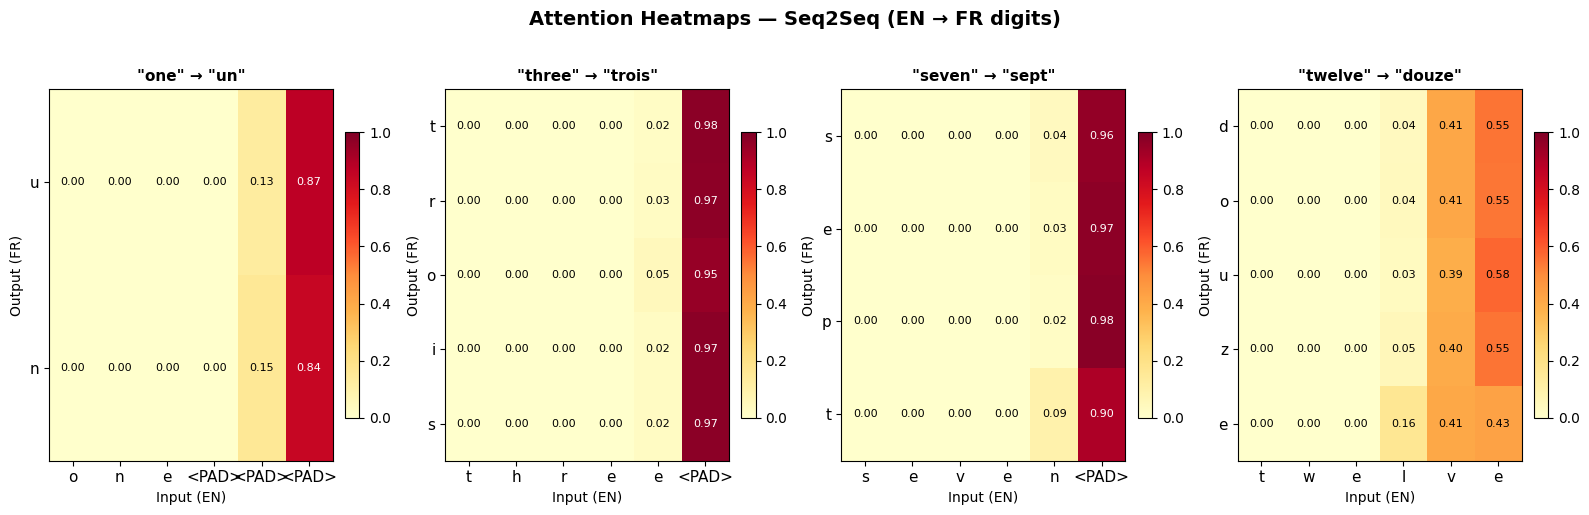

Saved → attention_heatmaps.png


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import Layer
import tensorflow.keras.backend as K

# ── 1. Tiny Dataset: English → French digits ────────────────
pairs = [
    ("one",   "un"),   ("two",    "deux"),  ("three", "trois"),
    ("four",  "quatre"),("five",  "cinq"),  ("six",   "six"),
    ("seven", "sept"), ("eight",  "huit"),  ("nine",  "neuf"),
    ("ten",   "dix"),  ("eleven", "onze"),  ("twelve","douze"),
]

# ── 2. Character Vocabularies ───────────────────────────────
src_chars = ['<PAD>'] + sorted(set(''.join(p[0] for p in pairs)))
tgt_chars = ['<PAD>', '<S>', '</S>'] + sorted(set(''.join(p[1] for p in pairs)))

s2i = {c:i for i,c in enumerate(src_chars)}
t2i = {c:i for i,c in enumerate(tgt_chars)}
i2t = {i:c for c,i in t2i.items()}

SRC_VOCAB = len(src_chars)
TGT_VOCAB = len(tgt_chars)
SRC_LEN   = max(len(p[0]) for p in pairs)
TGT_LEN   = max(len(p[1]) for p in pairs) + 2

def encode_src(s):
    seq = [s2i[c] for c in s]
    return seq + [0] * (SRC_LEN - len(seq))

def encode_tgt(s):
    seq = [t2i['<S>']] + [t2i[c] for c in s] + [t2i['</S>']]
    return seq + [0] * (TGT_LEN - len(seq))

X  = np.array([encode_src(p[0]) for p in pairs])
Y  = np.array([encode_tgt(p[1]) for p in pairs])

# ── 3. Bahdanau Attention Layer ─────────────────────────────
class BahdanauAttention(Layer):
    def __init__(self, units):
        super().__init__()
        self.W1 = tf.keras.layers.Dense(units)
        self.W2 = tf.keras.layers.Dense(units)
        self.V  = tf.keras.layers.Dense(1)

    def call(self, query, values):
        # query : (batch, hidden)  → (batch, 1, hidden)
        # values: (batch, src_len, hidden)
        query_exp = tf.expand_dims(query, 1)
        score     = self.V(tf.nn.tanh(self.W1(values) + self.W2(query_exp)))
        weights   = tf.nn.softmax(score, axis=1)          # (batch, src_len, 1)
        context   = weights * values                       # broadcast
        context   = tf.reduce_sum(context, axis=1)        # (batch, hidden)
        return context, weights

# ── 4. Build Encoder ────────────────────────────────────────
UNITS    = 64
EMBED    = 32

enc_in  = tf.keras.Input((SRC_LEN,))
enc_emb = tf.keras.layers.Embedding(SRC_VOCAB, EMBED)(enc_in)
enc_out, enc_h, enc_c = tf.keras.layers.LSTM(
    UNITS, return_sequences=True, return_state=True)(enc_emb)

encoder = tf.keras.Model(enc_in, [enc_out, enc_h, enc_c])

# ── 5. Build Decoder (one step at a time) ───────────────────
attention = BahdanauAttention(UNITS)

dec_emb_layer = tf.keras.layers.Embedding(TGT_VOCAB, EMBED)
dec_lstm      = tf.keras.layers.LSTMCell(UNITS)
dec_dense     = tf.keras.layers.Dense(TGT_VOCAB, activation='softmax')

optimizer = tf.keras.optimizers.Adam()
loss_fn   = tf.keras.losses.SparseCategoricalCrossentropy()

# ── 6. Custom Training Loop ─────────────────────────────────
@tf.function
def train_step(x_batch, y_batch):
    with tf.GradientTape() as tape:
        enc_out, h, c = encoder(x_batch, training=True)
        loss = 0.0
        for t in range(TGT_LEN - 1):
            ctx, _   = attention(h, enc_out)
            token    = dec_emb_layer(y_batch[:, t])
            inp      = tf.concat([token, ctx], axis=-1)
            out, [h, c] = dec_lstm(inp, [h, c])
            pred     = dec_dense(out)
            loss    += loss_fn(y_batch[:, t+1], pred)

    vars_  = (encoder.trainable_variables +
              attention.trainable_variables +
              dec_emb_layer.trainable_variables +
              dec_lstm.trainable_variables +
              dec_dense.trainable_variables)
    grads = tape.gradient(loss, vars_)
    optimizer.apply_gradients(zip(grads, vars_))
    return loss

print("Training...")
for epoch in range(1, 401):
    loss = train_step(X, Y)
    if epoch % 100 == 0:
        print(f"  Epoch {epoch:4d} | Loss: {loss.numpy():.4f}")

# ── 7. Inference + Collect Attention Weights ─────────────────
def translate_with_attention(word):
    x = np.array([encode_src(word)])
    enc_out, h, c = encoder(x, training=False)
    h, c = h.numpy(), c.numpy()

    token  = np.array([[t2i['<S>']]])
    result = []
    attn_matrix = []                        # shape: (tgt_steps, src_len)

    for _ in range(TGT_LEN):
        ctx, weights = attention(h, enc_out)
        attn_matrix.append(weights.numpy()[0, :, 0])  # (src_len,)

        emb      = dec_emb_layer(token)[:, 0, :]
        inp      = tf.concat([emb, ctx], axis=-1)
        out, [h, c] = dec_lstm(inp.numpy(), [h, c])
        pred     = dec_dense(out)
        idx      = np.argmax(pred.numpy()[0])
        ch       = i2t[idx]
        if ch == '</S>':
            break
        result.append(ch)
        token = np.array([[idx]])

    return ''.join(result), np.array(attn_matrix)   # (tgt_steps, src_len)

# ── 8. Plot Attention Heatmaps ───────────────────────────────
test_words = ["one", "three", "seven", "twelve"]

fig, axes = plt.subplots(1, len(test_words),
                         figsize=(4 * len(test_words), 5))
fig.suptitle("Attention Heatmaps — Seq2Seq (EN → FR digits)",
             fontsize=14, fontweight='bold', y=1.02)

for ax, word in zip(axes, test_words):
    translation, attn = translate_with_attention(word)

    src_labels = list(word) + ['<PAD>'] * (SRC_LEN - len(word))
    tgt_labels = list(translation)

    # Crop attn to actual output length
    attn_crop = attn[:len(tgt_labels), :SRC_LEN]

    im = ax.imshow(attn_crop, cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)
    ax.set_xticks(range(SRC_LEN));     ax.set_xticklabels(src_labels, fontsize=11)
    ax.set_yticks(range(len(tgt_labels))); ax.set_yticklabels(tgt_labels, fontsize=11)
    ax.set_xlabel("Input (EN)", fontsize=10)
    ax.set_ylabel("Output (FR)", fontsize=10)
    ax.set_title(f'"{word}" → "{translation}"', fontsize=11, fontweight='bold')

    # Annotate weights
    for i in range(attn_crop.shape[0]):
        for j in range(attn_crop.shape[1]):
            ax.text(j, i, f"{attn_crop[i,j]:.2f}",
                    ha='center', va='center', fontsize=8,
                    color='black' if attn_crop[i,j] < 0.6 else 'white')

    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig("attention_heatmaps.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved → attention_heatmaps.png")